# Fixing Corrupted Figure Text in the ReAct Paper

Three pages of the ReAct paper (`2210.03629`) in `data/curated_papers_text.json` contain corrupted text where a figure is embedded as real, extractable vector text — but drawn with a PDF font subset that has a broken/custom character encoding. The result is strings like:

```
$FW\x03\x14\x1d\x037KLQN>)LUVW\x03,\x03QHHG\x03WR\x03ILQG...
```

instead of the correct `Act 1: Think[First I need to find...`.

This notebook diagnoses the corruption, confirms it against the reference screenshots (`data/images/react_2.png`, `data/images/react_14.png`, `data/images/react_15.png`), and surgically replaces **only the corrupted spans** in `data/curated_papers_text.json` — leaving the rest of each page's text (including body paragraphs before/after each figure) untouched.

## 1. Diagnosis

Comparing the corrupted characters against the known-correct text visible in the reference images (e.g. `$FW` should read `Act`, `\x03` should be a space) reveals a **constant offset**: every corrupted character code is exactly **29 less** than its correct ASCII code.

```
'$' (0x24) + 29 = 0x41 = 'A'
'F' (0x46) + 29 = 0x63 = 'c'
'W' (0x57) + 29 = 0x74 = 't'
        ->  "Act"
```

This is a classic PDF text-extraction failure: the figure's text was drawn using a subsetted font whose internal glyph codes were never mapped back to real character codes (no `ToUnicode` CMap), so the extractor read raw glyph indices instead of letters.

A handful of characters don't fit the simple `+29` shift and were identified by inspecting their raw byte values in context against the images:

| Raw character | Meaning | Handling |
|---|---|---|
| `\n` (newline) | Genuine line-wrap in the figure's narrow text boxes (matches the images' visual line breaks) | kept as a literal newline |
| `\n` immediately between two lowercase letters | The one apostrophe in "Let's" — the font reuses the newline byte for the apostrophe glyph | replaced with `'` |
| `\xaa` (ª) | Ellipsis glyph (`...`) | replaced with `...` |
| `Ҽ` (Ѥ) | Decorative checkmark icon marking a successful trajectory — not real text | dropped |
| `ѕ` (ѕ) | Space glyph specific to the bold/colored "Think" keyword's font run | replaced with a space |
| `q` (0x71) | Accented `è`, e.g. "Myst`q`re" -> "Myst`è`re" — a separate accent-glyph font run outside the normal shift range | replaced with `è` |
| literal `0x20` space | A plain space that happens to fall inside the shift range but was never actually encoded — confirmed by checking it never appears as a shift-source byte elsewhere in the span | left as-is, excluded from the shift |

This was verified against **all** distinct characters in every span (via frequency counts) before finalizing, and the fully decoded output was checked line-by-line against the reference images.

In [1]:
import json
import re
from pathlib import Path

DATA_PATH = Path("../data/curated_papers_text.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    papers = json.load(f)

react = next(p for p in papers if p["id"] == "2210.03629")
print(react["title"])

ReAct: Synergizing Reasoning and Acting in Language Models


In [2]:
def decode_shifted_span(s: str) -> str:
    """Reverse the broken PDF font's +29 character-code shift, with a few
    special-cased glyphs identified by comparing against the reference images
    (see markdown above for the full table)."""
    out = []
    for c in s:
        o = ord(c)
        if c == "\n":
            out.append("\n")
        elif o == 0x20:
            out.append(" ")
        elif 0x03 <= o <= 0x5C:
            out.append(chr(o + 29))
        elif o == 0xAA:
            out.append("...")
        elif o == 0x4BC:
            out.append("")
        elif o == 0x455:
            out.append(" ")
        elif o == 0x71:
            out.append("è")  # accented 'e' (e.g. "Mystere" -> "Mystère"), separate accent-glyph font run
        else:
            out.append(c)
    decoded = "".join(out)
    # the one apostrophe ("Let's") reuses the newline byte; every other \n is a
    # genuine line-wrap, so only fix the case where it sits directly between
    # two lowercase letters with no surrounding whitespace.
    decoded = re.sub(r"(?<=[a-z])\n(?=[a-z])", "'", decoded)
    return decoded

## 2. Locate and Replace the Corrupted Spans

All three corrupted spans end exactly where the page returns to normal, correctly-extracted text (a literal `"Figure N:"` caption, or for page 15 the shift-encoded word `"AlfWorld"` immediately followed by one):

- **Page 2**: starts right after `"Published as a conference paper at ICLR 2023\n"`, ends at `"Figure 1:"`.
- **Page 15**: starts right after the same header, ends right after the corrupted text decodes to `"AlfWorld"` (found by searching for the *shift-encoded* form of that word, since the caption immediately following it is already correct plain text).
- **Page 14**: starts right after the section heading `"A.2 REAC T OBTAINS UP -TO-DATE KNOWLEDGE ON HOTPOT QA\n"` (this page has a full paragraph of correctly-extracted text before the corrupted figure begins), ends at `"Figure 4:"`.

Everything outside these three spans is left untouched.

In [3]:
HEADER_MARKER = "ICLR 2023\n"


def is_already_fixed(span: str) -> bool:
    """True if a span has no leftover shift-cipher control characters, meaning
    it's already been decoded. Lets this cell be safely re-run without
    double-shifting already-correct text into new gibberish."""
    return not any(c != "\n" and ord(c) <= 0x1C for c in span)


def fix_page(page: dict, start_marker: str, end_marker: str, end_is_shift_encoded: bool = False) -> str:
    text = page["text"]
    start = text.index(start_marker) + len(start_marker)

    if end_is_shift_encoded:
        raw_marker = "".join(chr(ord(c) - 29) for c in end_marker)
        idx = text.find(raw_marker, start)
        if idx != -1:
            end = idx + len(raw_marker)
        else:
            # raw (shift-encoded) marker not found -> already decoded, so the
            # plain marker itself should be present instead.
            end = text.index(end_marker, start) + len(end_marker)
    else:
        end = text.index(end_marker, start)

    span = text[start:end]
    if is_already_fixed(span):
        print(f"Page {page['page_number']}: span already decoded -- skipping (safe to re-run).")
        return text

    return text[:start] + decode_shifted_span(span) + text[end:]


page2 = next(pg for pg in react["pages"] if pg["page_number"] == 2)
page14 = next(pg for pg in react["pages"] if pg["page_number"] == 14)
page15 = next(pg for pg in react["pages"] if pg["page_number"] == 15)

old_texts = {2: page2["text"], 14: page14["text"], 15: page15["text"]}

page2["text"] = fix_page(page2, HEADER_MARKER, "Figure 1:")
page14["text"] = fix_page(page14, "A.2 REAC T OBTAINS UP -TO-DATE KNOWLEDGE ON HOTPOT QA\n", "Figure 4:")
page15["text"] = fix_page(page15, HEADER_MARKER, "AlfWorld", end_is_shift_encoded=True)

print("Page 2 changed:", page2["text"] != old_texts[2])
print("Page 14 changed:", page14["text"] != old_texts[14])
print("Page 15 changed:", page15["text"] != old_texts[15])

Page 2: span already decoded -- skipping (safe to re-run).
Page 15: span already decoded -- skipping (safe to re-run).
Page 2 changed: False
Page 14 changed: True
Page 15 changed: False


## 3. Verify Against the Reference Images

===== react_2.png =====


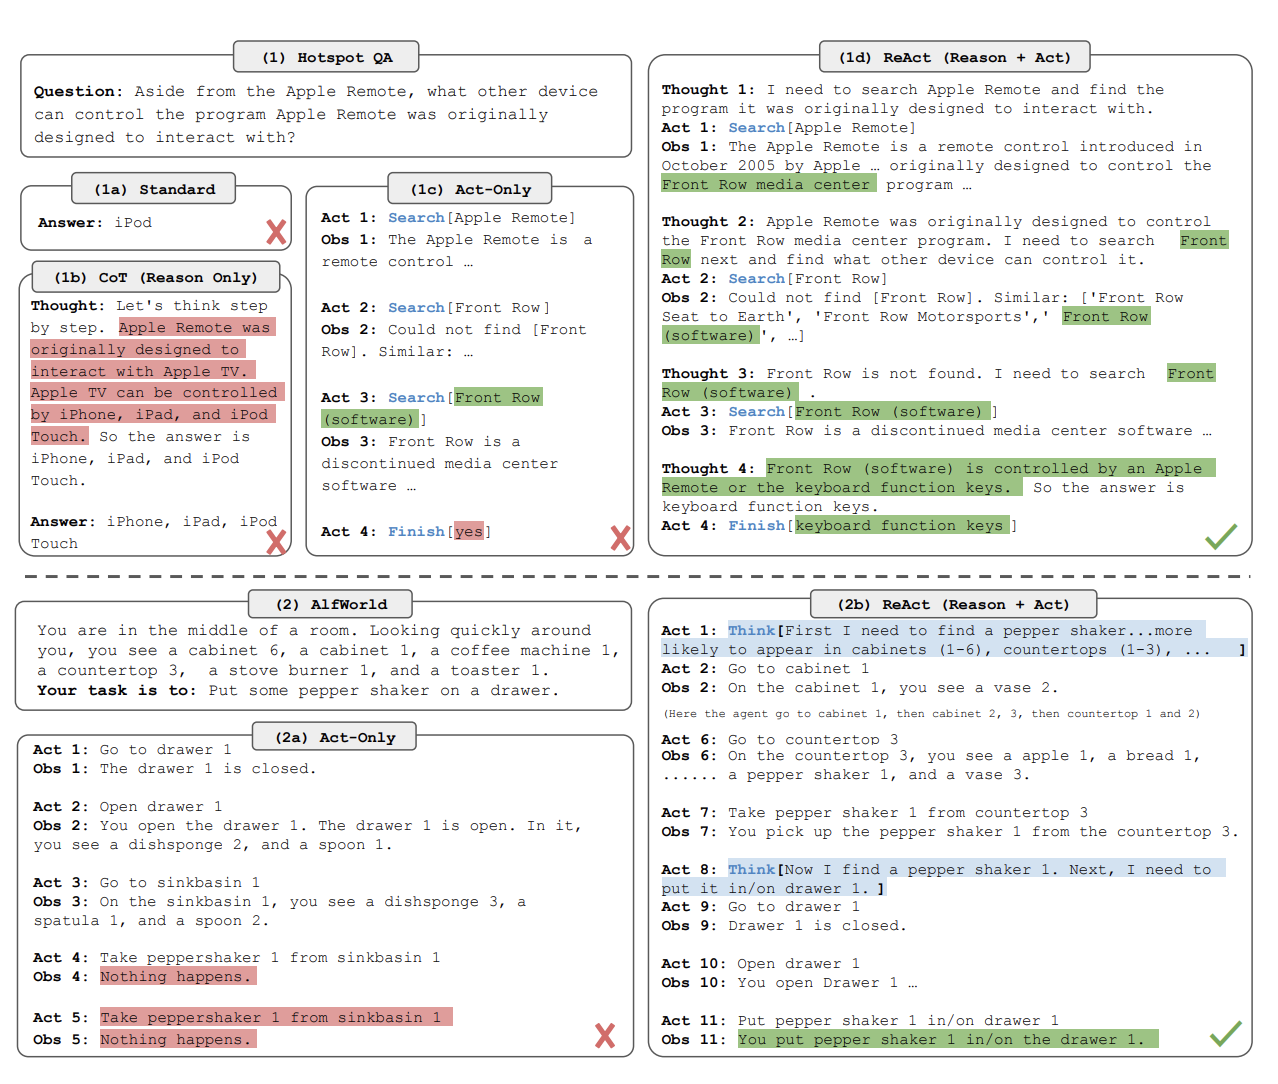

Published as a conference paper at ICLR 2023
Act 1: Think[First I need to find a pepper shaker...more 
likely to appear in cabinets (1-6), countertops (1-3), ... ]
Act 2: Go to cabinet 1 
Obs 2: On the cabinet 1, you see a vase 2. 
(Here the agent go to cabinet 1, then cabinet 2, 3, then countertop 1 and 2)
Act 6: Go to countertop 3 Obs 6: On the countertop 3, you see a apple 1, a bread 1, 
...... a pepper shaker 1, and a vase 3.
Act 7: Take pepper shaker 1 from countertop 3 
Obs 7: You pick up the pepper shaker 1 from the countertop 3. 
Act 8: Think[Now I find a pepper shaker 1. Next, I need to 
put it in/on drawer 1.]
Act 9: Go to drawer 1 
Obs 9: Drawer 1 is closed. 
Act 10: Open drawer 1 
Obs 10: You open Drawer 1 ...
Act 11: Put pepper shaker 1 in/on drawer 1 
Obs 11: You put pepper shaker 1 in/on the drawer 1.
(1a) Standard
Answer: iPod
(1b) CoT (Reason Only)
Thought: Let's think step 
by step. Apple Remote was 
originally designed to 
interact with Apple TV. 
Apple TV can be con

In [4]:
from PIL import Image

print("===== react_2.png =====")
display(Image.open("../data/images/react_2.png"))
print(page2["text"][: page2["text"].index("Figure 1:") + 200])

===== react_15.png =====


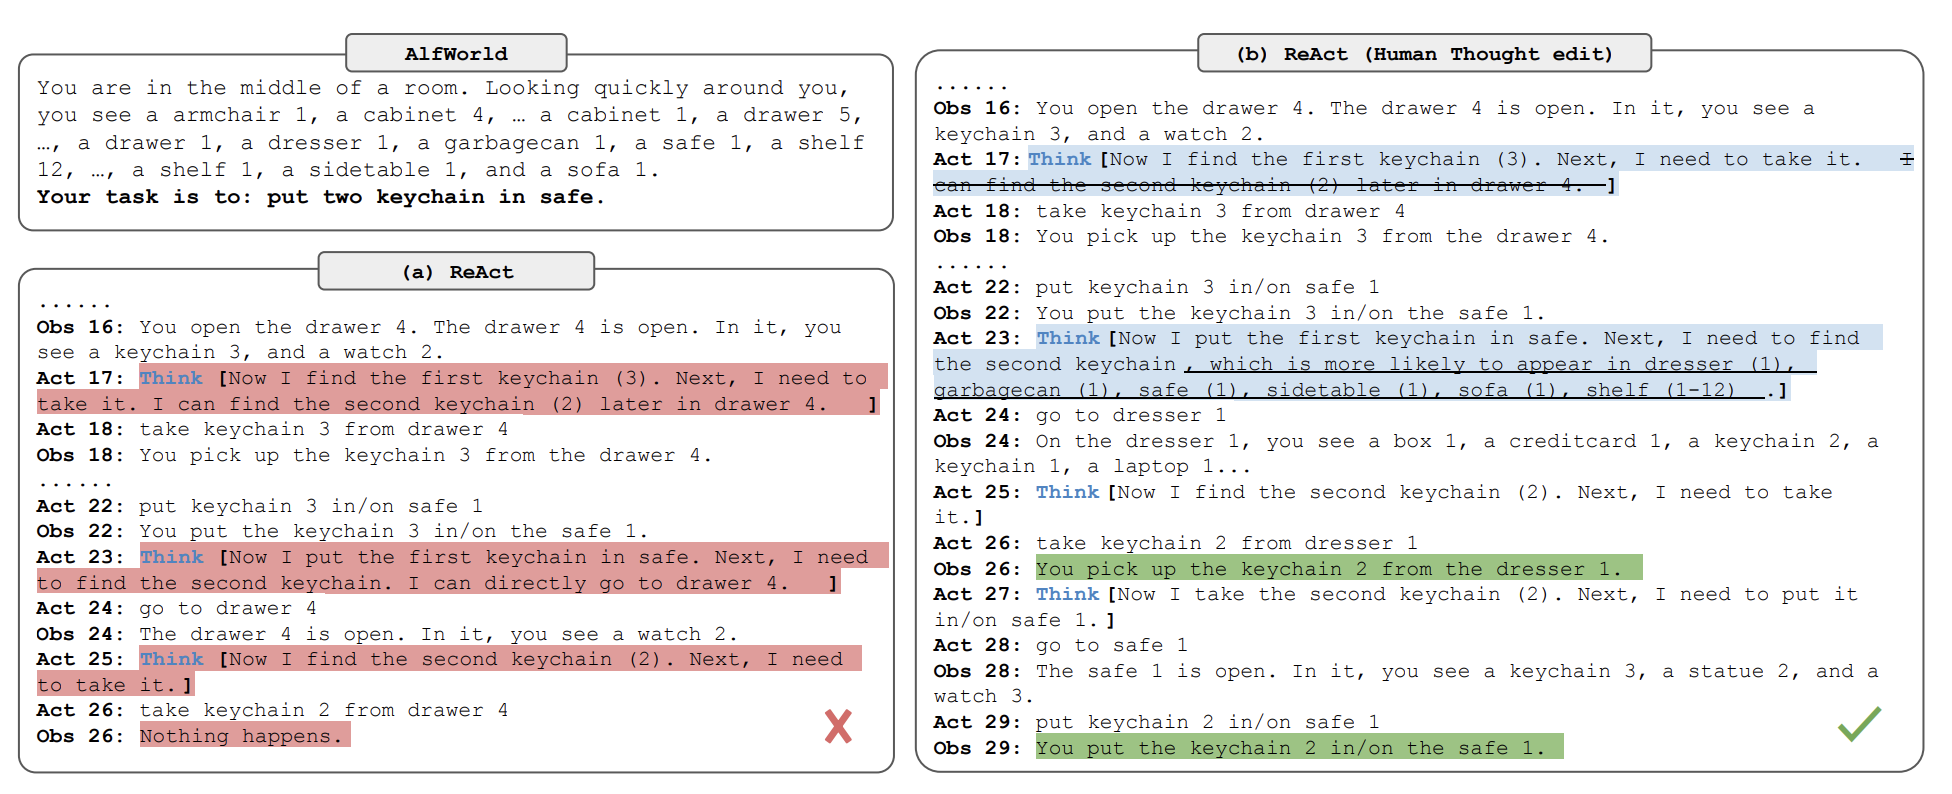

Published as a conference paper at ICLR 2023
(a) ReAct 
......
Obs 16: You open the drawer 4. The drawer 4 is open. In it, you 
see a keychain 3, and a watch 2. 
Act 17: Think [Now I find the first keychain (3). Next, I need to 
take it. I can find the second keychain (2) later in drawer 4. ]
Act 18: take keychain 3 from drawer 4 
Obs 18: You pick up the keychain 3 from the drawer 4. 
......
Act 22: put keychain 3 in/on safe 1 
Obs 22: You put the keychain 3 in/on the safe 1. 
Act 23: Think [Now I put the first keychain in safe. Next, I need 
to find the second keychain. I can directly go to drawer 4. ]
Act 24: go to drawer 4 
Obs 24: The drawer 4 is open. In it, you see a watch 2. 
Act 25: Think [Now I find the second keychain (2). Next, I need 
to take it.]
Act 26: take keychain 2 from drawer 4 
Obs 26: Nothing happens.
(b) ReAct (Human Thought edit)
......
Obs 16: You open the drawer 4. The drawer 4 is open. In it, you see a 
keychain 3, and a watch 2. 
Act 17: Think [Now I find the

In [5]:
print("===== react_15.png =====")
display(Image.open("../data/images/react_15.png"))
print(page15["text"][: page15["text"].index("Figure 5:") + 200])

===== react_14.png =====


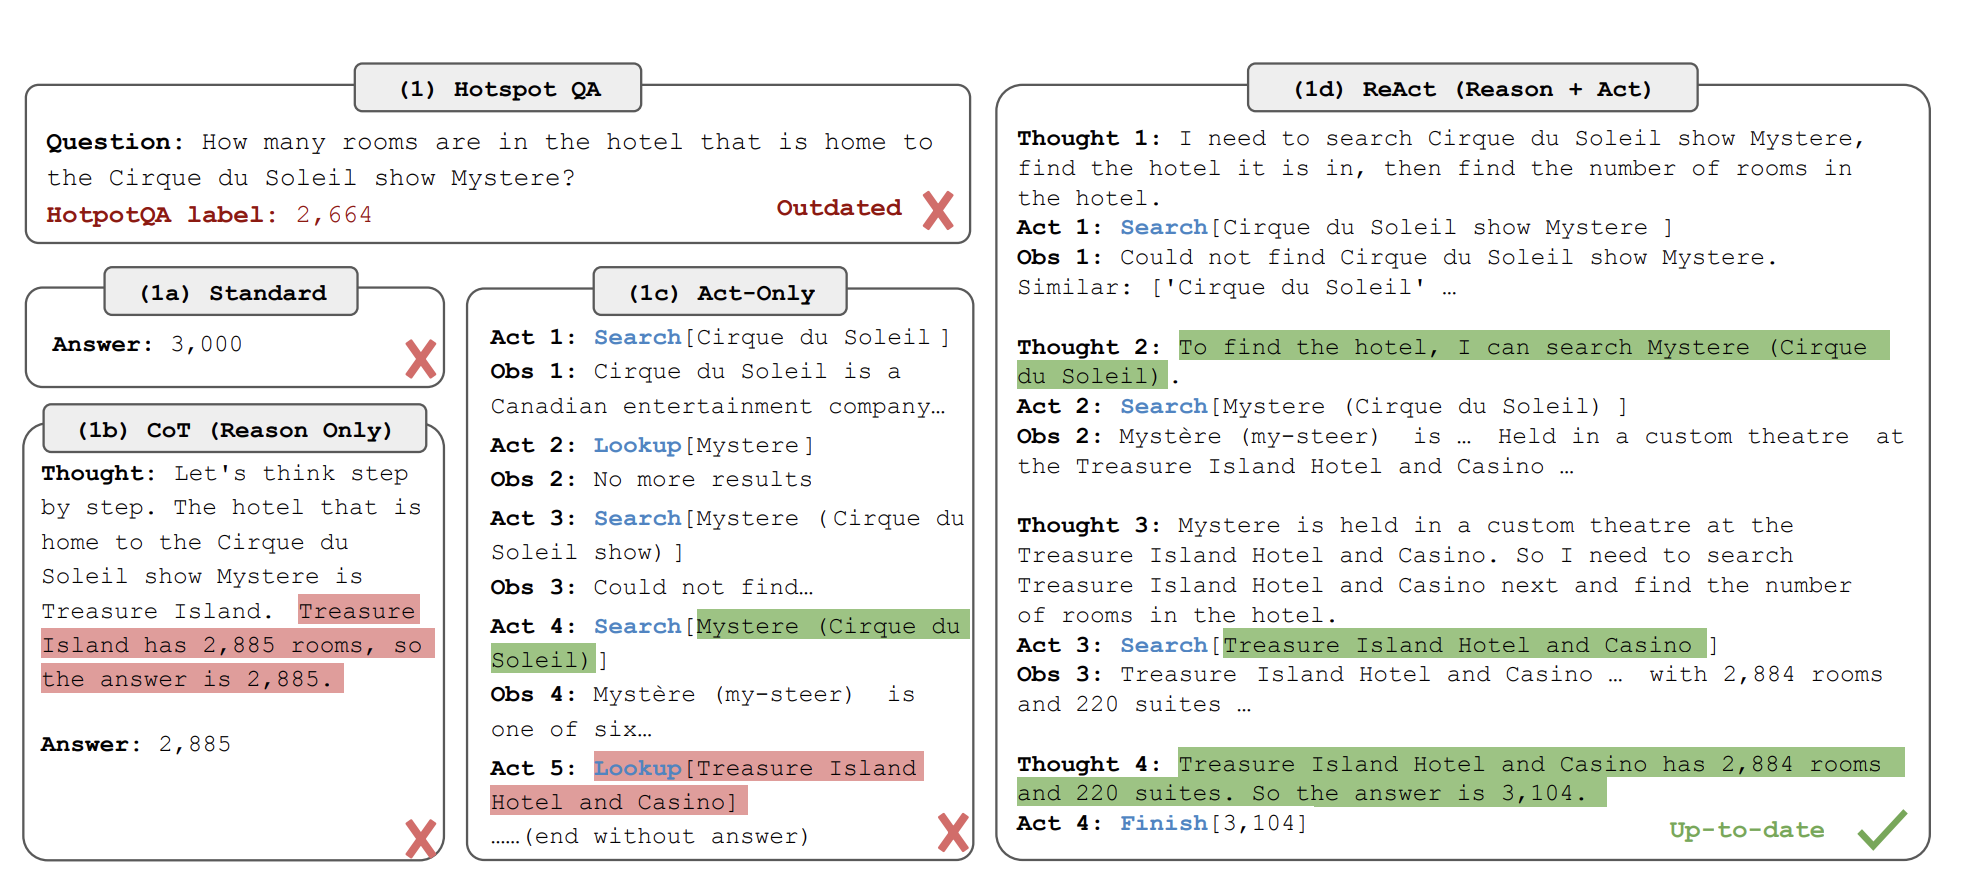

Published as a conference paper at ICLR 2023
A A DDITIONAL RESULTS
A.1 GPT-3 E XPERIMENTS
PaLM-540B GPT-3
HotpotQA (exact match) 29.4 30.8
ALFWorld (success rate %) 70.9 78.4
Table 5: ReAct prompting results using PaLM-540B vs. GPT-3 (text-davinci-002, greedy decoding).
On HotpotQA, we randomly sample a subset of 500 validation questions. On ALFWorld, we use all
134 unseen validation task instances, and use the best prompt set according to PaLM-540B.
We run additional GPT-3 (Brown et al., 2020) experiments to conﬁrmReAct prompting performance
is general across different large language models. As shown in Table 5, GPT-3 (text-davinci-002,
greedy decoding) consistently outperforms PaLM-540B on HotpotQA and ALFWorld, possibly
because it is ﬁnetuned with human instruction following. This indicates ReAct prompting is effective
across different large language models on different tasks. The code for these experiments are at
https://react-lm.github.io/.
A.2 REAC T OBTAINS UP -TO-DATE KNOWLEDGE

In [6]:
print("===== react_14.png =====")
display(Image.open("../data/images/react_14.png"))
print(page14["text"][: page14["text"].index("Figure 4:") + 200])

## 4. Save the Corrected Dataset

In [7]:
with open(DATA_PATH, "w", encoding="utf-8") as f:
    json.dump(papers, f, ensure_ascii=False, indent=2)

print(f"Saved corrected dataset to {DATA_PATH}")

Saved corrected dataset to ../data/curated_papers_text.json


## Notes / Scope

- **Fixed:** all three spans depicted in `react_2.png` (page 2, Figure 1), `react_14.png` (page 14, Figure 4), and `react_15.png` (page 15, Figure 5) — all fully recovered via the deterministic `+29` shift (plus the handful of special-cased glyphs above). This is a lossless decode, not OCR, so it's more reliable than the image-based OCR approach used elsewhere in this project.
- **This cell is idempotent:** re-running it against already-fixed pages detects the span is already decoded and skips it (see `is_already_fixed` above), so it's safe to re-run without risk of double-corrupting the text.
- **Minor known cosmetic losses:** the bracketed list `Similar: ['Front Row Seat to Earth', 'Front Row Motorsports', ...]` on page 2 loses its quote marks (the font's line-wrap and quote-mark glyphs appear to collide in a way that couldn't be reliably disambiguated from the raw bytes alone) — the words themselves are all correct, just missing the surrounding `'...'` punctuation. This is a trivial stylistic gap, not a content error.